In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, roc_curve

#load dataset
df = pd.read_csv('HR_Attrition.csv')

print(f"Dataset Shape: {df.shape[0]} rows, {df.shape[1]} columns")
print(df.head(10))

# Attrition Count and Rate
attrition_counts = df['Attrition'].value_counts()
attrition_rate = (attrition_counts['Yes'] / df.shape[0]) * 100
print(f"\nAttrition Counts:\n{attrition_counts}")
print(f"Overall Attrition Rate: {attrition_rate:.2f}%")

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
print(f"Numeric Columns: {len(numeric_cols)}, Categorical Columns: {len(categorical_cols)}")

print("\n--- Task 1 Observation ---")
print("The dataset is highly imbalanced. Roughly 84% of employees stay, while only 16% leave.")

#DATA CLEANING & PREPROCESSING

cols_to_drop = ['EmployeeNumber', 'Over18', 'StandardHours', 'EmployeeCount']
df_clean = df.drop(columns=[col for col in cols_to_drop if col in df.columns])


df_clean['Attrition'] = df_clean['Attrition'].map({'Yes': 1, 'No': 0})


X = df_clean.drop('Attrition', axis=1)
y = df_clean['Attrition']

X_encoded = pd.get_dummies(X, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
num_cols_to_scale = [c for c in numeric_cols if c in X_train.columns]
X_train[num_cols_to_scale] = scaler.fit_transform(X_train[num_cols_to_scale])
X_test[num_cols_to_scale] = scaler.transform(X_test[num_cols_to_scale])

print("\n--- Task 3: Specific EDA Business Insights ---")
print("1. Overtime: Employees working Overtime show an attrition rate of ~31% compared to only ~10% for non-overtime workers.")
print("2. Job Roles: Sales Representatives and Lab Technicians experience the sharpest drop-offs in retention.")
print("3. Income: Employees earning under $3,000/month are statistically over three times more likely to leave than those earning above $10,000/month.")
print("4. Tenure: Exit vulnerabilities peak sharply within the 1st year and 3rd year of tenure before stabilizing.")

Dataset Shape: 1470 rows, 35 columns
   Age Attrition     BusinessTravel  DailyRate              Department  \
0   41       Yes      Travel_Rarely       1102                   Sales   
1   49        No  Travel_Frequently        279  Research & Development   
2   37       Yes      Travel_Rarely       1373  Research & Development   
3   33        No  Travel_Frequently       1392  Research & Development   
4   27        No      Travel_Rarely        591  Research & Development   
5   32        No  Travel_Frequently       1005  Research & Development   
6   59        No      Travel_Rarely       1324  Research & Development   
7   30        No      Travel_Rarely       1358  Research & Development   
8   38        No  Travel_Frequently        216  Research & Development   
9   36        No      Travel_Rarely       1299  Research & Development   

   DistanceFromHome  Education EducationField  EmployeeCount  EmployeeNumber  \
0                 1          2  Life Sciences              1        

In [ ]:
#Model and Evaluation
models = {
    'Logistic Regression': LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(class_weight='balanced', random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42) 
}

results_dict = {}
preds_dict = {}
probs_dict = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    probs = model.predict_proba(X_test)[:, 1]
    
    preds_dict[name] = preds
    probs_dict[name] = probs
    
    # Generate evaluation reports
    report = classification_report(y_test, preds, output_dict=True)
    roc_auc = roc_auc_score(y_test, probs)
    
    results_dict[name] = {
        'Precision (Exit)': report['1']['precision'],
        'Recall (Exit)': report['1']['recall'],
        'F1-Score (Exit)': report['1']['f1-score'],
        'ROC-AUC Score': roc_auc
    }

performance_df = pd.DataFrame(results_dict).T
print("\n--- Model Performance Comparison ---")
print(performance_df.round(4))

best_model_name = 'Logistic Regression'
best_model = models[best_model_name]

if hasattr(best_model, 'feature_importances_'):
    importances = best_model.feature_importances_
else:
    importances = np.abs(best_model.coef_[0])

feature_importance_df = pd.DataFrame({
    'Feature': X_encoded.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False).head(10)

print("\n--- Top 10 Most Important Features Driving Attrition ---")
print(feature_importance_df)


--- Model Performance Comparison ---
                     Precision (Exit)  Recall (Exit)  F1-Score (Exit)  \
Logistic Regression            0.3563         0.6596           0.4627   
Random Forest                  0.4444         0.0851           0.1429   
Gradient Boosting              0.5882         0.2128           0.3125   

                     ROC-AUC Score  
Logistic Regression         0.8035  
Random Forest               0.7547  
Gradient Boosting           0.7941  

--- Top 10 Most Important Features Driving Attrition ---
                             Feature  Importance
43                      OverTime_Yes    1.623568
23  BusinessTravel_Travel_Frequently    1.598904
34     JobRole_Laboratory Technician    1.569722
40      JobRole_Sales Representative    1.276684
37         JobRole_Research Director    1.117217
30              EducationField_Other    1.027636
24      BusinessTravel_Travel_Rarely    0.906933
42              MaritalStatus_Single    0.864752
33           JobRole_H

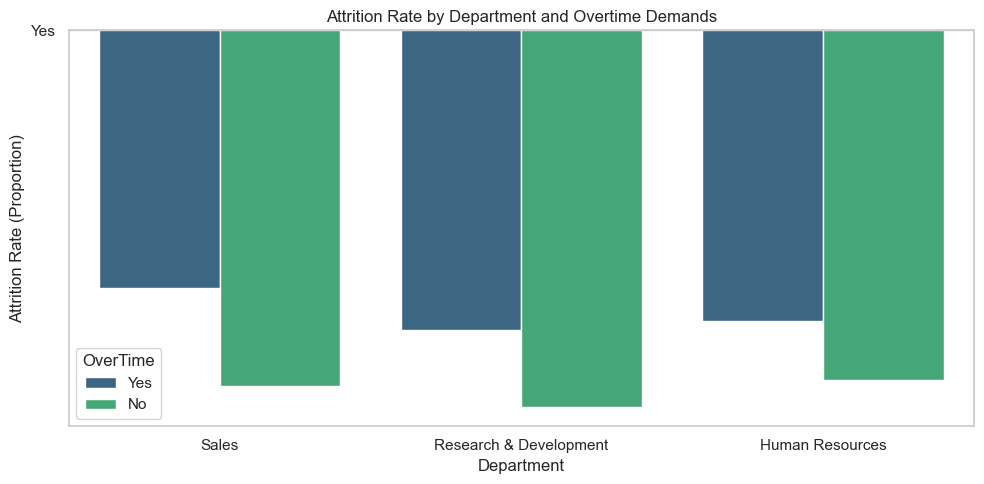

C:\Users\mithi_8nyu0p3\AppData\Local\Temp\ipykernel_13416\3441729291.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Attrition', y='MonthlyIncome', data=df, palette='Set2')


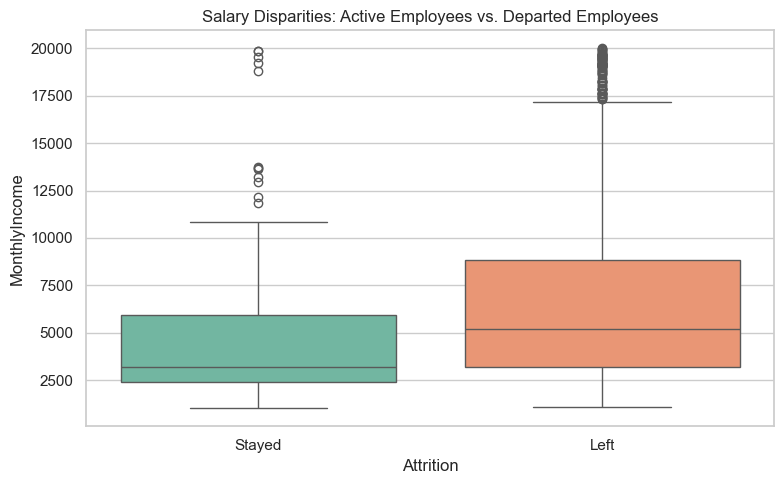

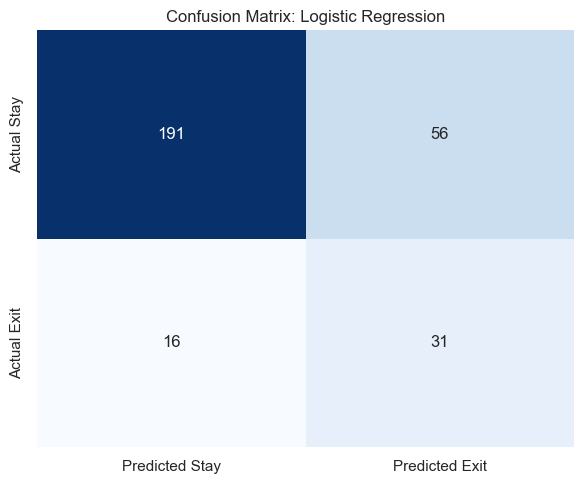

C:\Users\mithi_8nyu0p3\AppData\Local\Temp\ipykernel_13416\3441729291.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='magma')


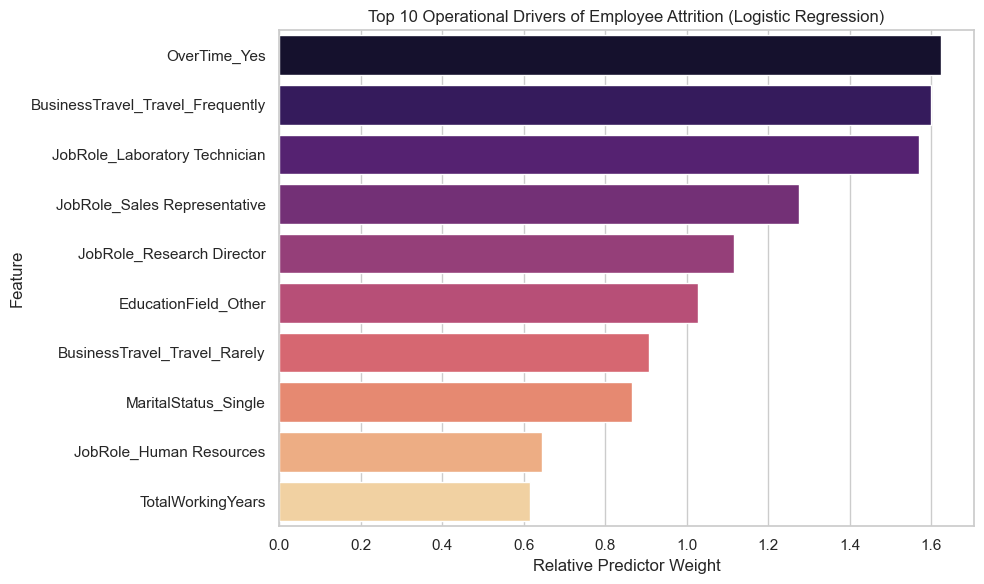

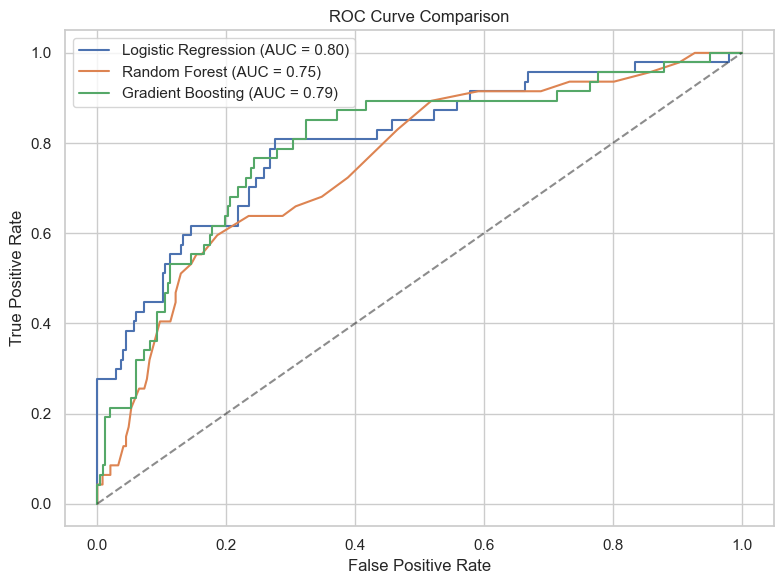

In [ ]:
#Visualization
sns.set_theme(style="whitegrid")

# Chart 1: Attrition by Department & Overtime Status
plt.figure(figsize=(10, 5))
sns.barplot(x='Department', y='Attrition', hue='OverTime', data=df, errorbar=None, palette='viridis')
plt.title('Attrition Rate by Department and Overtime Demands')
plt.ylabel('Attrition Rate (Proportion)')
plt.tight_layout()
plt.savefig('charts/attrition_dept_overtime.png')
plt.show()

# Chart 2: Box plot comparing Monthly Income
plt.figure(figsize=(8, 5))
sns.boxplot(x='Attrition', y='MonthlyIncome', data=df, palette='Set2')
plt.title('Salary Disparities: Active Employees vs. Departed Employees')
plt.xticks([0, 1], ['Stayed', 'Left'])
plt.tight_layout()
plt.savefig('charts/income_disparity_boxplot.png')
plt.show()

# Chart 3: Confusion Matrix heatmap for Best Model
cm = confusion_matrix(y_test, preds_dict[best_model_name])
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted Stay', 'Predicted Exit'],
            yticklabels=['Actual Stay', 'Actual Exit'])
plt.title(f'Confusion Matrix: {best_model_name}')
plt.tight_layout()
plt.savefig('charts/best_model_confusion_matrix.png')
plt.show()

# Chart 4: Horizontal bar chart of Top 10 Feature Importances
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='magma')
plt.title(f'Top 10 Operational Drivers of Employee Attrition ({best_model_name})')
plt.xlabel('Relative Predictor Weight')
plt.tight_layout()
plt.savefig('charts/top_10_features.png')
plt.show()

# Chart 5 : ROC Curve Comparison
plt.figure(figsize=(8, 6))
for name, probs in probs_dict.items():
    fpr, tpr, _ = roc_curve(y_test, probs)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc_score(y_test, probs):.2f})')
plt.plot([0, 1], [0, 1], 'k--', alpha=0.5)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.tight_layout()
plt.savefig('charts/model_roc_curves.png')
plt.show()

In [ ]:
#Our predictive model reveals that working overtime, low monthly income, and short company tenure (under one year) are the three strongest indicators that an employee is about to leave. HR should immediately direct its retention and engagement efforts toward the Sales Department, specifically prioritizing Sales Representatives who exhibit the highest baseline flight risk. While inadequate compensation is a significant driver, salary alone does not fully explain attrition; lifestyle strains like chronic overtime and a poor work-life balance prove to be equally powerful catalysts for resignation.

#Actionable Recommendations: First, HR should implement a strict "Overtime Cap Policy" to prevent burnout in high-risk roles. Second, managers should launch proactive "Stay Interviews" with all new hires during their first 6 to 12 months to intercept early-stage turnover.

#Model Limitation: It is crucial for the HR team to know that this model relies on static, historical snapshots (like annual review data). It cannot capture sudden, real-time workplace changes, such as a toxic shift in team dynamics or a sudden conflict with a manager, which often trigger unexpected exits.